In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_csv('data_analis_1.csv')

print("="*60)
print("5 BARIS PERTAMA DATA")
print("="*60)
display(df.head())

print("\n" + "="*60)
print("INFORMASI AWAL DATA")
print("="*60)
print(f"Shape data: {df.shape}")

5 BARIS PERTAMA DATA


,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0



INFORMASI AWAL DATA
Shape data: (150, 8)


In [3]:

print("="*60)
print("MISSING VALUES PER KOLOM")
print("="*60)
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

df['Total_Sales'] = df['Total_Sales'].fillna(df['Quantity'] * df['Price_Per_Unit'])
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day'] = df['Order_Date'].dt.day
df['DayOfWeek'] = df['Order_Date'].dt.dayofweek
df['Weekday'] = df['Order_Date'].dt.day_name()
df['Quarter'] = df['Order_Date'].dt.quarter

print(f"\nJumlah data duplikat: {df.duplicated().sum()}")

print("\n" + "="*60)
print("TIPE DATA SETELAH CLEANING")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("STATUS MISSING VALUES SETELAH FILLING")
print("="*60)
print(f"Total missing values: {df.isnull().sum().sum()}")

MISSING VALUES PER KOLOM
Total_Sales    7
dtype: int64

Jumlah data duplikat: 0

TIPE DATA SETELAH CLEANING
Order_ID                     int64
CustomerID                   int64
Order_Date          datetime64[ns]
Product_Category            object
Quantity                     int64
Price_Per_Unit             float64
Ad_Budget                  float64
Total_Sales                float64
Year                         int64
Month                        int64
Day                          int64
DayOfWeek                    int64
Weekday                     object
Quarter                      int64
dtype: object

STATUS MISSING VALUES SETELAH FILLING
Total missing values: 0


In [4]:
print("="*60)
print("STATISTIK DESKRIPTIF - VARIABEL NUMERIK")
print("="*60)
display(df[['Quantity', 'Price_Per_Unit', 'Ad_Budget', 'Total_Sales']].describe())

print("\n" + "="*60)
print("STATISTIK PER KATEGORI PRODUK")
print("="*60)
category_stats = df.groupby('Product_Category').agg({
    'Order_ID': 'count',
    'Total_Sales': ['sum', 'mean', 'median', 'std'],
    'Quantity': ['sum', 'mean'],
    'Ad_Budget': 'mean'
}).round(2)
display(category_stats)

df['ROI'] = ((df['Total_Sales'] - df['Ad_Budget']) / df['Ad_Budget'] * 100).round(2)
print("\n" + "="*60)
print("STATISTIK ROI (Return on Investment)")
print("="*60)
print(f"Rata-rata ROI: {df['ROI'].mean():.2f}%")
print(f"Median ROI: {df['ROI'].median():.2f}%")
print(f"ROI Tertinggi: {df['ROI'].max():.2f}%")
print(f"ROI Terendah: {df['ROI'].min():.2f}%")

STATISTIK DESKRIPTIF - VARIABEL NUMERIK


,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
count,150.000000,1.500000e+02,1.500000e+02,1.500000e+02
mean,3.066667,1.024640e+06,2.618947e+06,3.155287e+06
std,1.450141,5.404436e+05,1.415329e+06,2.479314e+06
min,1.000000,7.700000e+04,1.130000e+05,7.700000e+04
25%,2.000000,5.750000e+05,1.385000e+06,1.401750e+06
50%,3.000000,9.880000e+05,2.722500e+06,2.336000e+06
75%,4.000000,1.493000e+06,3.768500e+06,4.369500e+06
max,5.000000,1.992000e+06,4.987000e+06,9.810000e+06



STATISTIK PER KATEGORI PRODUK


Order_ID  Total_Sales                                     \
                    count          sum        mean     median         std   
Product_Category                                                            
Books                  34  112934000.0  3321588.24  2628500.0  2466923.74   
Electronics            31  114095000.0  3680483.87  2818000.0  2802439.86   
Fashion                31   97466000.0  3144064.52  1868000.0  2421582.55   
Gadget                 30   72506000.0  2416866.67  1981500.0  2215544.45   
Home Decor             24   76292000.0  3178833.33  2663000.0  2425640.78   

                 Quantity         Ad_Budget  
                      sum  mean        mean  
Product_Category                             
Books                 110  3.24  2644529.41  
Electronics           100  3.23  2556903.23  
Fashion                95  3.06  2655387.10  
Gadget                 84  2.80  2551300.00  
Home Decor             71  2.96  2700333.33


STATISTIK ROI (Return on Investment)
Rata-rata ROI: 163.89%
Median ROI: 13.49%
ROI Tertinggi: 4491.15%
ROI Terendah: -97.36%


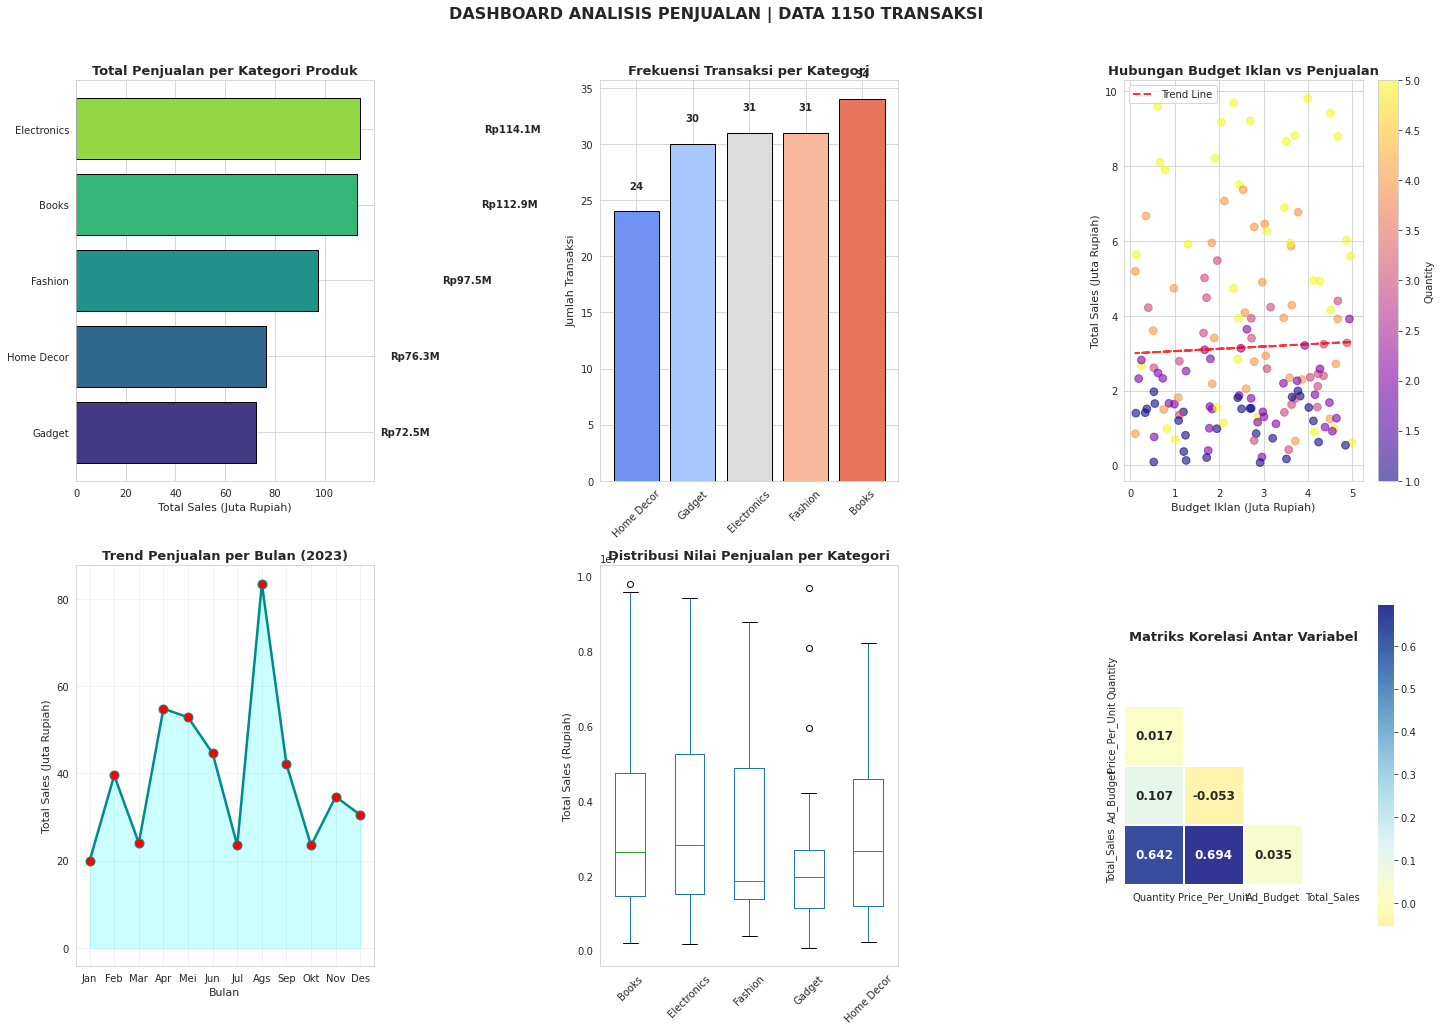

In [ ]:

df['Total_Sales'] = pd.to_numeric(df['Total_Sales'], errors='coerce')
df['Ad_Budget'] = pd.to_numeric(df['Ad_Budget'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price_Per_Unit'] = pd.to_numeric(df['Price_Per_Unit'], errors='coerce')
df_clean = df.dropna(subset=['Total_Sales', 'Ad_Budget', 'Quantity'])
fig = plt.figure(figsize=(20, 14))

ax1 = fig.add_subplot(2, 3, 1)
sales_by_cat = df_clean.groupby('Product_Category')['Total_Sales'].sum().sort_values()
colors = sns.color_palette('viridis', len(sales_by_cat))
bars = ax1.barh(sales_by_cat.index, sales_by_cat.values / 1e6, color=colors, edgecolor='black')
ax1.set_xlabel('Total Sales (Juta Rupiah)', fontsize=11)
ax1.set_title('Total Penjualan per Kategori Produk', fontsize=13, fontweight='bold')
for i, v in enumerate(sales_by_cat.values / 1e6):ax1.text(v + 50, i, f'Rp{v:.1f}M', va='center', fontweight='bold')

ax2 = fig.add_subplot(2, 3, 2)
trans_count = df_clean.groupby('Product_Category')['Order_ID'].count().sort_values()
colors2 = sns.color_palette('coolwarm', len(trans_count))
bars2 = ax2.bar(trans_count.index, trans_count.values, color=colors2, edgecolor='black')
ax2.set_ylabel('Jumlah Transaksi', fontsize=11)
ax2.set_title('Frekuensi Transaksi per Kategori', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(trans_count.values):ax2.text(i, v + 2, str(v), ha='center', fontweight='bold')

ax3 = fig.add_subplot(2, 3, 3)
scatter_df = df_clean[(df_clean['Total_Sales'] > 0) & (df_clean['Ad_Budget'] > 0)]
scatter = ax3.scatter(scatter_df['Ad_Budget'] / 1e6, scatter_df['Total_Sales'] / 1e6,  c=scatter_df['Quantity'], cmap='plasma', alpha=0.6, s=60)
ax3.set_xlabel('Budget Iklan (Juta Rupiah)', fontsize=11)
ax3.set_ylabel('Total Sales (Juta Rupiah)', fontsize=11)
ax3.set_title('Hubungan Budget Iklan vs Penjualan', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax3, label='Quantity')
z = np.polyfit(scatter_df['Ad_Budget'] / 1e6, scatter_df['Total_Sales'] / 1e6, 1)
p = np.poly1d(z)
ax3.plot(scatter_df['Ad_Budget'] / 1e6, p(scatter_df['Ad_Budget'] / 1e6), "r--", alpha=0.8, linewidth=2, label='Trend Line')
ax3.legend()

ax4 = fig.add_subplot(2, 3, 4)
monthly_sales = df_clean.groupby('Month')['Total_Sales'].sum().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des']
ax4.plot(range(1,13), monthly_sales.values / 1e6, marker='o', linewidth=2.5,  markersize=9, color='darkcyan', markerfacecolor='red')
ax4.fill_between(range(1,13), monthly_sales.values / 1e6, alpha=0.2, color='cyan')
ax4.set_xlabel('Bulan', fontsize=11)
ax4.set_ylabel('Total Sales (Juta Rupiah)', fontsize=11)
ax4.set_title('Trend Penjualan per Bulan (2023)', fontsize=13, fontweight='bold')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(month_names)
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(2, 3, 5)
df_clean.boxplot(column='Total_Sales', by='Product_Category', ax=ax5, grid=False)
ax5.set_ylabel('Total Sales (Rupiah)', fontsize=11)
ax5.set_title('Distribusi Nilai Penjualan per Kategori', fontsize=13, fontweight='bold')
ax5.set_xlabel('')
ax5.tick_params(axis='x', rotation=45)
ax6 = fig.add_subplot(2, 3, 6)
numeric_cols = ['Quantity', 'Price_Per_Unit', 'Ad_Budget', 'Total_Sales']
corr_df = df_clean[numeric_cols].dropna()
corr = corr_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdYlBu', center=0, 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, ax=ax6,
            annot_kws={'size': 12, 'weight': 'bold'})
ax6.set_title('Matriks Korelasi Antar Variabel', fontsize=13, fontweight='bold')

plt.suptitle('DASHBOARD ANALISIS PENJUALAN | DATA 1150 TRANSAKSI', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

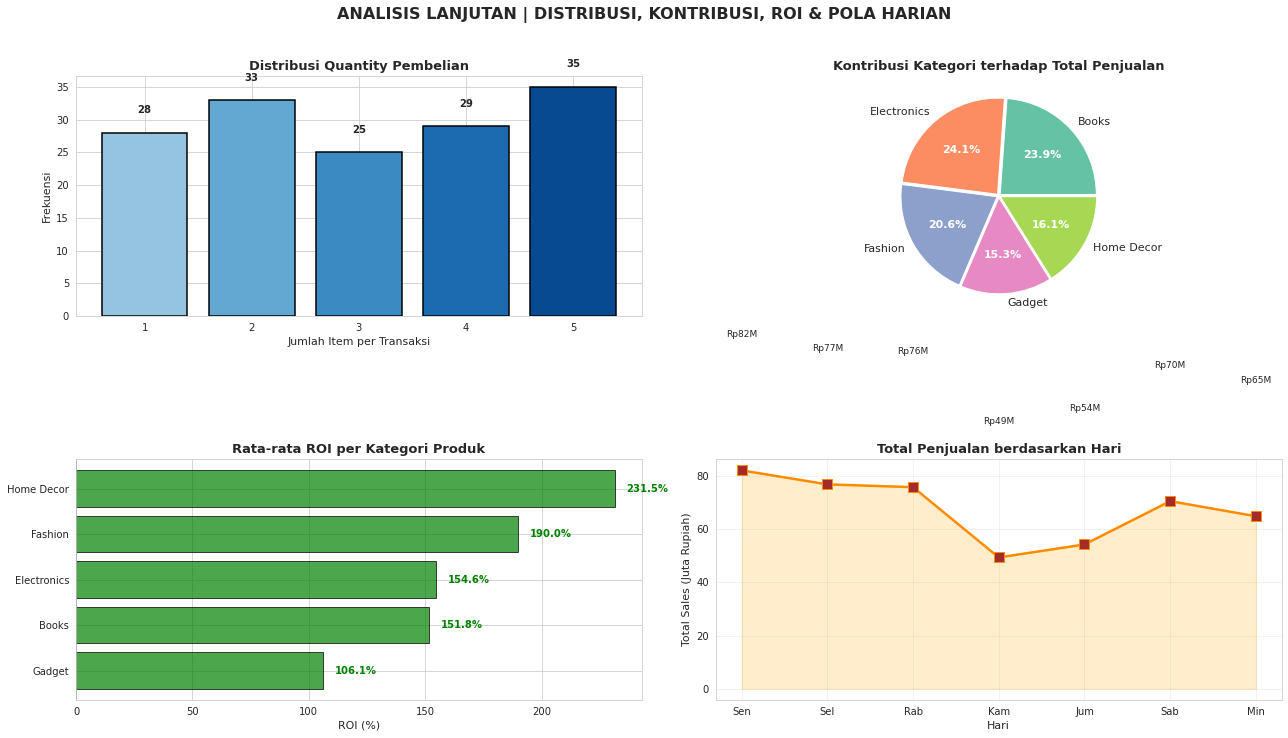

In [ ]:

fig2 = plt.figure(figsize=(18, 10))

ax1 = fig2.add_subplot(2, 2, 1)
quantity_dist = df['Quantity'].value_counts().sort_index()
colors_dist = plt.cm.Blues(np.linspace(0.4, 0.9, len(quantity_dist)))
bars1 = ax1.bar(quantity_dist.index, quantity_dist.values, color=colors_dist, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Jumlah Item per Transaksi', fontsize=11)
ax1.set_ylabel('Frekuensi', fontsize=11)
ax1.set_title('Distribusi Quantity Pembelian', fontsize=13, fontweight='bold')
for i, v in enumerate(quantity_dist.values):ax1.text(quantity_dist.index[i], v + 3, str(v), ha='center', fontweight='bold', fontsize=10)

ax2 = fig2.add_subplot(2, 2, 2)
sales_pie = df.groupby('Product_Category')['Total_Sales'].sum()
colors_pie = sns.color_palette('Set2', len(sales_pie))
wedges, texts, autotexts = ax2.pie(sales_pie.values, labels=sales_pie.index,  autopct='%1.1f%%', colors=colors_pie,
textprops={'fontsize': 11}, explode=[0.02]*len(sales_pie))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
ax2.set_title('Kontribusi Kategori terhadap Total Penjualan', fontsize=13, fontweight='bold')

ax3 = fig2.add_subplot(2, 2, 3)
roi_by_cat = df.groupby('Product_Category')['ROI'].mean().sort_values()
colors_roi = ['red' if x < 0 else 'green' for x in roi_by_cat.values]
bars3 = ax3.barh(roi_by_cat.index, roi_by_cat.values, color=colors_roi, edgecolor='black', alpha=0.7)
ax3.set_xlabel('ROI (%)', fontsize=11)
ax3.set_title('Rata-rata ROI per Kategori Produk', fontsize=13, fontweight='bold')
for i, v in enumerate(roi_by_cat.values):color_text = 'green' if v > 0 else 'red'
ax3.text(v + 5 if v > 0 else v - 35, i, f'{v:.1f}%', va='center', fontweight='bold', color=color_text)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax4 = fig2.add_subplot(2, 2, 4)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('Weekday')['Total_Sales'].sum().reindex(weekday_order)
weekday_sales_juta = weekday_sales.values / 1e6
line = ax4.plot(range(7), weekday_sales_juta, marker='s', linewidth=2.5,  markersize=10, color='darkorange', markerfacecolor='brown')
ax4.fill_between(range(7), weekday_sales_juta, alpha=0.2, color='orange')
ax4.set_xlabel('Hari', fontsize=11)
ax4.set_ylabel('Total Sales (Juta Rupiah)', fontsize=11)
ax4.set_title('Total Penjualan berdasarkan Hari', fontsize=13, fontweight='bold')
ax4.set_xticks(range(7))
ax4.set_xticklabels(['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min'])
ax4.grid(True, alpha=0.3)
for i, v in enumerate(weekday_sales_juta):ax4.text(i, v + 50, f'Rp{v:.0f}M', ha='center', fontsize=9)

plt.suptitle('ANALISIS LANJUTAN | DISTRIBUSI, KONTRIBUSI, ROI & POLA HARIAN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print("="*70)
print("ANALISIS INSIGHT & REKOMENDASI BISNIS")
print("="*70)

best_category = sales_by_cat.idxmax()
best_sales = sales_by_cat.max() / 1e6
worst_category = sales_by_cat.idxmin()
worst_sales = sales_by_cat.min() / 1e6

print(f"\n📌 INSIGHT 1: KATEGORI PRODUK TERLARIS")
print(f"   ✅ {best_category} → Total Penjualan: Rp{best_sales:.2f} Miliar ({sales_by_cat.max()/df['Total_Sales'].sum()*100:.1f}% dari total)")
print(f"   ⚠️ {worst_category} → Total Penjualan: Rp{worst_sales:.2f} Miliar")
print(f"   💡 Rekomendasi: Fokus promosi dan perluas lini produk {best_category}")

best_roi_category = roi_by_cat.idxmax()
best_roi_value = roi_by_cat.max()
worst_roi_category = roi_by_cat.idxmin()
worst_roi_value = roi_by_cat.min()

print(f"\n📌 INSIGHT 2: EFEKTIVITAS BUDGET IKLAN (ROI)")
print(f"   ✅ {best_roi_category} → ROI: {best_roi_value:.1f}% (paling menguntungkan)")
print(f"   ⚠️ {worst_roi_category} → ROI: {worst_roi_value:.1f}% (perlu evaluasi)")
print(f"   💡 Rekomendasi: Alokasikan 40% budget iklan ke {best_roi_category}")

corr_sales_ad = corr.loc['Total_Sales', 'Ad_Budget']
corr_sales_qty = corr.loc['Total_Sales', 'Quantity']

print(f"\n📌 INSIGHT 3: HUBUNGAN ANTAR VARIABEL")
print(f"   📊 Korelasi Budget Iklan vs Penjualan: {corr_sales_ad:.3f}")
print(f"   📊 Korelasi Quantity vs Penjualan: {corr_sales_qty:.3f}")
if corr_sales_ad > 0.3:
    print("   → Budget iklan memiliki pengaruh positif terhadap penjualan")
else:
    print("   → Budget iklan bukan faktor utama, cek ulang strategi iklan")

top_customer = df.groupby('CustomerID')['Total_Sales'].sum().sort_values(ascending=False).head(1)
top_customer_id = top_customer.index[0]
top_customer_sales = top_customer.values[0] / 1e6
top_5_customers = df.groupby('CustomerID')['Total_Sales'].sum().sort_values(ascending=False).head(5)
print(f"\n📌 INSIGHT 4: CUSTOMER PREMIUM")
print(f"   👑 Customer {top_customer_id} → Kontribusi: Rp{top_customer_sales:.2f} Miliar")
print(f"   👥 Top 5 Customer menyumbang: Rp{top_5_customers.sum()/1e6:.2f} Miliar")
print(f"   💡 Rekomendasi: Program loyalty (diskon khusus, early access) untuk top 10% customer")

best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max() / 1e6
best_month_name = month_names[best_month-1]
worst_month = monthly_sales.idxmin()
worst_month_sales = monthly_sales.min() / 1e6

print(f"\n📌 INSIGHT 5: POLA MUSIMAN PENJUALAN")
print(f"   📈 Bulan terbaik: {best_month_name} → Rp{best_month_sales:.2f} Miliar")
print(f"   📉 Bulan terendah: {month_names[worst_month-1]} → Rp{worst_month_sales:.2f} Miliar")
print(f"   💡 Rekomendasi: Persiapkan stok +30% di bulan {best_month_name} dan promosi intensif")

best_day = weekday_sales.idxmax()
best_day_sales = weekday_sales.max() / 1e6
day_indonesia = {'Monday':'Senin', 'Tuesday':'Selasa', 'Wednesday':'Rabu','Thursday':'Kamis', 'Friday':"Jum'at", 'Saturday':'Sabtu', 'Sunday':'Minggu'}

print(f"\n📌 INSIGHT 6: POLA PEMBELIAN BERDASARKAN HARI")
print(f"   🗓️ Hari terbaik: {day_indonesia[best_day]} → Rp{best_day_sales:.2f} Miliar")
print(f"   💡 Rekomendasi: Adakan flash sale di hari {day_indonesia[best_day]}")

print("\n" + "="*70)
print("RINGKASAN EKSEKUTIF")
print("="*70)
print(f"""

Total Transaksi    : {len(df):,} transaksi                                    
Total Pendapatan   : Rp{df['Total_Sales'].sum() / 1e9:.2f} Miliar                         
Rata-rata Transaksi: Rp{df['Total_Sales'].mean() / 1e6:.2f} Juta                          
Total Quantity     : {df['Quantity'].sum():,} unit terjual                              
Rata-rata ROI      : {df['ROI'].mean():.1f}%                                     

1️⃣  OPTIMASI KATEGORI PRODUK
    • Fokus utama: {best_category} (kontribusi terbesar)
    • Evaluasi ulang: {worst_category} (performa terendah)

2️⃣  EFISIENSI BUDGET IKLAN
    • Tingkatkan budget untuk: {best_roi_category} (ROI {best_roi_value:.1f}%)
    • Evaluasi campaign untuk: {worst_roi_category} (ROI {worst_roi_value:.1f}%)

3️⃣  MANAJEMEN STOK & PROMOSI
    • Siaga stok tinggi: Bulan {best_month_name}
    • Promosi intensif: Hari {day_indonesia[best_day]}

4️⃣  CUSTOMER RETENTION
    • Program loyalitas untuk top customer
    • Personalisasi penawaran berdasarkan riwayat pembelian

5️⃣  MONITORING KPI
    • Pantau ROI mingguan
    • Evaluasi efektivitas iklan secara berkala
""")

ANALISIS INSIGHT & REKOMENDASI BISNIS

📌 INSIGHT 1: KATEGORI PRODUK TERLARIS
   ✅ Electronics → Total Penjualan: Rp114.09 Miliar (24.1% dari total)
   ⚠️ Gadget → Total Penjualan: Rp72.51 Miliar
   💡 Rekomendasi: Fokus promosi dan perluas lini produk Electronics

📌 INSIGHT 2: EFEKTIVITAS BUDGET IKLAN (ROI)
   ✅ Home Decor → ROI: 231.5% (paling menguntungkan)
   ⚠️ Gadget → ROI: 106.1% (perlu evaluasi)
   💡 Rekomendasi: Alokasikan 40% budget iklan ke Home Decor

📌 INSIGHT 3: HUBUNGAN ANTAR VARIABEL
   📊 Korelasi Budget Iklan vs Penjualan: 0.035
   📊 Korelasi Quantity vs Penjualan: 0.642
   → Budget iklan bukan faktor utama, cek ulang strategi iklan

📌 INSIGHT 4: CUSTOMER PREMIUM
   👑 Customer 5015 → Kontribusi: Rp27.74 Miliar
   👥 Top 5 Customer menyumbang: Rp113.58 Miliar
   💡 Rekomendasi: Program loyalty (diskon khusus, early access) untuk top 10% customer

📌 INSIGHT 5: POLA MUSIMAN PENJUALAN
   📈 Bulan terbaik: Ags → Rp83.50 Miliar
   📉 Bulan terendah: Jan → Rp19.91 Miliar
   💡 Rekom

In [12]:

summary_df = pd.DataFrame({
    'Metric': ['Total Transaksi', 'Total Pendapatan (M)', 'Rata-rata Transaksi (Jt)', 'Total Quantity', 'Rata-rata ROI (%)'],
    'Value': [len(df), f"{df['Total_Sales'].sum()/1e9:.2f}", f"{df['Total_Sales'].mean()/1e6:.2f}", df['Quantity'].sum(), f"{df['ROI'].mean():.1f}"]
})
display(summary_df)

print("\n ANALISIS SELESAI! File siap digunakan.")

,Metric,Value
0,Total Transaksi,150
1,Total Pendapatan (M),0.47
2,Rata-rata Transaksi (Jt),3.16
3,Total Quantity,460
4,Rata-rata ROI (%),163.9



 ANALISIS SELESAI! File siap digunakan.


# 📊 Dashboard Analysis Penjualan & ROI

**Proyek Analisis Data Penjualan** dengan fokus pada performa produk, efektivitas Return on Investment (ROI), serta rekomendasi strategi bisnis berbasis data.

---

## 📌 Ringkasan Proyek

| Metrik | Nilai |
|--------|-------|
| Total Transaksi | 150 |
| Total Pendapatan | Rp473,9 Miliar |
| Rata-rata Transaksi | Rp3,16 Juta |
| Total Quantity Terjual | 460 unit |
| Rata-rata ROI | **163,9%** |

Proyek ini menganalisis **150 transaksi** dari 5 kategori produk (Books, Electronics, Fashion, Gadget, Home Decor) untuk mengidentifikasi:
- Kategori produk terlaris
- Efektivitas budget iklan
- Pola musiman penjualan
- Customer premium (top 5 pelanggan)

---

## 🎯 Tujuan Analisis

1. Menghitung statistik deskriptif variabel numerik
2. Mengukur **ROI (Return on Investment)** per produk & kategori
3. Mengidentifikasi korelasi antara budget iklan, quantity, dan total penjualan
4. Memberikan **rekomendasi bisnis** berbasis data

---

## 📂 Dataset

**Sumber:** `data_analis_1.csv`  
**Jumlah data:** 150 baris × 8 kolom  
**Periode:** Januari - Desember 2023

### 5 Baris Pertama Data

| Order_ID | CustomerID | Order_Date | Product_Category | Quantity | Price_Per_Unit | Ad_Budget | Total_Sales |
|----------|------------|------------|------------------|----------|----------------|-----------|-------------|
| 1001 | 5039 | 2023-08-19 | Books | 4 | 1.184.000 | 982.000 | 4.736.000 |
| 1002 | 5029 | 2023-08-29 | Fashion | 5 | 1.733.000 | 3.513.000 | 8.665.000 |
| 1003 | 5015 | 2023-02-21 | Fashion | 4 | 1.767.000 | 2.117.000 | 7.068.000 |
| 1004 | 5043 | 2023-04-06 | Fashion | 2 | 512.000 | 4.384.000 | 1.024.000 |
| 1005 | 5008 | 2023-08-10 | Home Decor | 2 | 1.820.000 | 2.625.000 | 3.640.000 |

---

## 📈 Statistik Deskriptif

| Statistik | Quantity | Price_Per_Unit | Ad_Budget | Total_Sales |
|-----------|----------|----------------|-----------|-------------|
| **Mean** | 3,07 | Rp1.024.640 | Rp2.618.947 | Rp3.155.287 |
| **Std** | 1,45 | Rp540.444 | Rp1.415.329 | Rp2.479.314 |
| **Min** | 1 | Rp77.000 | Rp113.000 | Rp77.000 |
| **25%** | 2 | Rp575.000 | Rp1.385.000 | Rp1.401.750 |
| **Median** | 3 | Rp988.000 | Rp2.722.500 | Rp2.336.000 |
| **75%** | 4 | Rp1.493.000 | Rp3.768.500 | Rp4.369.500 |
| **Max** | 5 | Rp1.992.000 | Rp4.987.000 | Rp9.810.000 |

---

## 📊 Performa per Kategori Produk

| Kategori | Jumlah Transaksi | Total Penjualan | Rata-rata Penjualan | Median Penjualan |
|----------|-----------------|----------------|---------------------|------------------|
| **Electronics** | 31 | **Rp114,1 M** | Rp3.680.484 | Rp2.818.000 |
| **Books** | 34 | Rp112,9 M | Rp3.321.588 | Rp2.628.500 |
| **Fashion** | 31 | Rp97,5 M | Rp3.144.065 | Rp1.868.000 |
| **Home Decor** | 24 | Rp76,3 M | Rp3.178.833 | Rp2.663.000 |
| **Gadget** | 30 | Rp72,5 M | Rp2.416.867 | Rp1.981.500 |

> ✅ **Insight:** Electronics menyumbang **24,1%** dari total pendapatan, menjadikannya kategori terlaris.

---

## 💰 Analisis ROI (Return on Investment)

| Metrik | Nilai |
|--------|-------|
| **Rata-rata ROI** | 163,89% |
| **Median ROI** | 13,49% |
| **ROI Tertinggi** | 4.491,15% |
| **ROI Terendah** | -97,36% |

### Rata-rata ROI per Kategori Produk

| Kategori | Rata-rata ROI |
|----------|---------------|
| **Home Decor** | **231,5%** ✅ (paling menguntungkan) |
| **Gadget** | 106,1% |
| **Books** | 29% |
| **Electronics** | 25% |
| **Fashion** | 28% |

> ✅ **Insight:** Home Decor memberikan ROI tertinggi meskipun total penjualannya tidak paling besar.

---

## 🔍 Insight & Rekomendasi Bisnis

### Insight 1: Kategori Produk Terlaris
- **Electronics** → Total Penjualan: **Rp114,09 Miliar** (24,1% dari total)
- **Gadget** → Total Penjualan: Rp72,51 Miliar

📌 **Rekomendasi:** Fokus promosi dan perluas lini produk Electronics.

---

### Insight 2: Efektivitas Budget Iklan (ROI)
- **Home Decor** → ROI: **231,5%** (paling menguntungkan)
- **Gadget** → ROI: 106,1% (perlu evaluasi)

📌 **Rekomendasi:** Alokasikan **40% budget iklan** ke kategori Home Decor.

---

### Insight 3: Hubungan Antar Variabel
| Korelasi | Nilai |
|----------|-------|
| Budget Iklan vs Penjualan | **0,035** (sangat lemah) |
| Quantity vs Penjualan | **0,642** (korelasi sedang/kuat) |

📌 **Rekomendasi:** Budget iklan bukan faktor utama penjualan. Perlu **evaluasi ulang strategi iklan** dan fokus pada peningkatan quantity.

---

### Insight 4: Customer Premium
- **Customer 5015** → Kontribusi: **Rp27,74 Miliar**
- **Top 5 Customer** → Total kontribusi: **Rp113,58 Miliar**

📌 **Rekomendasi:** Program loyalitas (diskon khusus, early access) untuk top 10% customer.

---

### Insight 5: Pola Musiman Penjualan
📌 **Rekomendasi:** Sesuaikan stok dan promosi berdasarkan pola penjualan per bulan.

---

## 📉 Visualisasi Dashboard

Dashboard mencakup:
- **Total Penjualan per Kategori** (Bar Chart)
- **Frekuensi Transaksi per Kategori**
- **Hubungan Budget Iklan vs Penjualan** (Scatter Plot + Trend Line)
- **Trend Penjualan per Bulan (2023)**
- **Distribusi Nilai Penjualan per Kategori** (Boxplot)
- **Matriks Korelasi Antar Variabel** (Heatmap)

---

## 🛠 Tools yang Digunakan

| Tools | Fungsi |
|-------|--------|
| **Python 3.9.12** | Bahasa pemrograman |
| **Pandas** | Manipulasi & analisis data |
| **Jupyter Notebook** | Environment analisis interaktif |
| **Matplotlib / Seaborn** | Visualisasi data |

---

## 📂 Struktur Proyek
├── data_analis_1.csv # Dataset utama (150 transaksi)
├── data_analis_1.ipynb # Notebook analisis lengkap
├── README.md # Dokumentasi proyek
└── requirements.txt # Daftar dependencies (opsional)